In [2]:
import numpy as np
import pandas as pd
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import sample_pt_model, sample_mvl_model
from src.context import get_context
from src.priors import sample_pt_prior, sample_mvl_prior

In [3]:
NUM_VAL_SIM = 1000
NUM_SAMPLES = 2000

In [4]:
context_gen = bf.simulation.ContextGenerator(
    batchable_context_fun=get_context
)

In [5]:
# theta = np.array([1, 0.9, 0.7])
# choices = np.zeros((100, 120))
# for i in range(100):
#     choices[i] = sample_pt_model(theta, context)
# np.mean(choices, axis=0).mean()

## PT Model

In [6]:
param_names = [r'$\lambda$', r'$\alpha$', r'$\tau$']

PT_PRIOR_MEANS = np.array([1.9, 0.6, 2.5])
PT_PRIOR_STDS = np.array([0.63, 0.34, 1.44])

In [7]:
prior = bf.simulation.Prior(
    batch_prior_fun=sample_pt_prior,
    param_names=param_names,
)

In [8]:
simulator = bf.simulation.Simulator(
    simulator_fun=sample_pt_model,
    context_generator=context_gen
)

model = bf.simulation.GenerativeModel(
    prior=prior,
    simulator=simulator,
    name="pt_model"
)

INFO:root:Performing 2 pilot runs with the pt_model model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 3)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 120)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes cares of that!


In [9]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [10]:
def configurator(forward_dict):
    out_dict = {}
    data = forward_dict["sim_data"][:, :, None]
    context = np.array(forward_dict["sim_batchable_context"]) / 100
    out_dict["summary_conditions"] = np.c_[data, context].astype(np.float32)
    params = forward_dict["prior_draws"].astype(np.float32)
    out_dict["parameters"] = (params - PT_PRIOR_MEANS) / PT_PRIOR_STDS
    return out_dict

In [11]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer = bf.trainers.Trainer(
    generative_model=model, 
    amortizer=amortizer, 
    configurator=configurator, 
    checkpoint_path=f"../checkpoints/{model.name}_2",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/pt_model_2/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/pt_model_2/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [12]:
val_data = model(NUM_VAL_SIM)
test_data = configurator(val_data)
true_params = val_data['prior_draws']

In [13]:
post_samples_z = amortizer.sample(test_data, NUM_SAMPLES)

In [14]:
post_samples = post_samples_z * PT_PRIOR_STDS + PT_PRIOR_MEANS

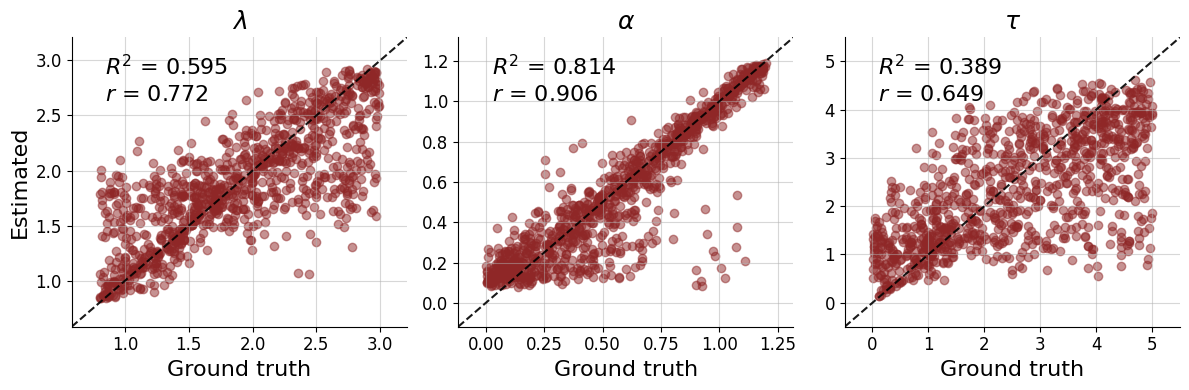

In [15]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=param_names,
    uncertainty_agg=None
)

In [ ]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=param_names,
    uncertainty_agg=None
)

## MVL Model

In [ ]:
parameter_names = [r'$\b_{var}$', r'$\b_{loss}$', r'$\tau$']

MVL_PRIOR_MEANS = np.array([0.3, 0.3, 0.5])
MVL_PRIOR_STDS = np.array([0.26, 0.26, 0.5])

In [ ]:
prior = bf.simulation.Prior(
    batch_prior_fun=sample_mvl_prior,
    param_names=parameter_names
)

In [ ]:
simulator = bf.simulation.Simulator(
    simulator_fun=sample_mvl_model,
    context_generator=context_gen
)

model = bf.simulation.GenerativeModel(
    prior=prior,
    simulator=simulator,
    name="mvl_model"
)

In [ ]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [ ]:
def configurator(forward_dict):
    out_dict = {}
    data = forward_dict["sim_data"][:, :, None]
    context = np.array(forward_dict["sim_batchable_context"]) / 200
    out_dict["summary_conditions"] = np.c_[data, context].astype(np.float32)
    params = forward_dict["prior_draws"]
    out_dict["parameters"] = ((params - MVL_PRIOR_MEANS) / MVL_PRIOR_STDS).astype(np.float32)
    return out_dict

In [ ]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer = bf.trainers.Trainer(
    generative_model=model, 
    amortizer=amortizer, 
    configurator=configurator, 
    checkpoint_path=f"../checkpoints/{model.name}",
    max_to_keep=1
)

In [ ]:
val_data = model(NUM_VAL_SIM)
test_data = configurator(val_data)
true_params = val_data['prior_draws']

In [ ]:
post_samples_z = amortizer.sample(test_data, NUM_SAMPLES)

In [ ]:
post_samples = post_samples_z * MVL_PRIOR_STDS + MVL_PRIOR_MEANS

In [ ]:
f = bf.diagnostics.plot_recovery(
    post_samples,
    true_params,
    param_names=['b_var', 'b_loss', 'tau'],
    uncertainty_agg=None
)